In [17]:
import matplotlib
import numpy as np
import pandas as pd
import pymc3 as pm
import random
import scipy as sp

import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
poiss_lam = 300.0
exp_scale = 0.5

# smaller value for the probability parameter in a geometric distribution
# leads to heavier tails. Thus, larger sample values are more probable.
geom_p_dur = 0.3
geom_p_dev = 0.2

global_size = 500

learn_window = 100

mad_thresh = 0.7

In [25]:
least_prob = 1.0

dev_val_vec = []
dur_val_vec = []
tot_prob_vec = []
rel_score_vec = []

# dev_val = np.random.exponential(scale=exp_scale, size=global_size)
# dur_val = np.random.poisson(lam=poiss_lam, size=global_size)
dur_val_vec = np.random.geometric(p=geom_p_dur, size=global_size)
dev_val_vec = np.random.geometric(p=geom_p_dev, size=global_size)

In [26]:
dur_train_vec = []
dev_train_vec = []

op_scores = []

train_samp_cnt = 0

In [27]:
for ip_cnt in range(global_size):
    dur_val = dur_val_vec[ip_cnt]
    dev_val = dev_val_vec[ip_cnt]

    if ip_cnt < learn_window:
        dur_train_vec.append(dur_val)
        dev_train_vec.append(dev_val)

        op_scores.append(mad_thresh)  # In the online system, the output is the MAD score.
        train_samp_cnt += 1
    else:
        if train_samp_cnt == learn_window:
            dev_model = pm.Model()
            dur_model = pm.Model()

            with dur_model:
                geom_p_dur_prior = pm.Uniform('geom_p_dur_prior', lower=0, upper=1)
                y_dur = pm.Geometric('y_dur', p=geom_p_dur_prior, observed=dur_train_vec)
                trace = pm.sample(2000, cores=1, chains=2, tune=1000)
                geom_p_dur_est = np.mean(trace['geom_p_dur_prior'])

            with dev_model:
                geom_p_dev_prior = pm.Uniform('geom_p_dev_prior', lower=0, upper=1)
                y_dev = pm.Geometric('y_dev', p=geom_p_dev_prior, observed=dev_train_vec)
                trace = pm.sample(2000, cores=1, chains=2, tune=1000)
                geom_p_dev_est = np.mean(trace['geom_p_dev_prior'])

            dur_geom_dist = pm.Geometric.dist(p=geom_p_dur_est)
            dur_prob = dur_geom_dist.logp(dur_val).eval()  # Log probability

            dev_geom_dist = pm.Geometric.dist(p=geom_p_dev_est)
            dev_prob = dev_geom_dist.logp(dev_val).eval()  # Log probability
            
            anom_least_prob = 0
            
            for dur_samp, dev_samp in zip(dur_train_vec, dev_train_vec):
                dur_samp_prob = dur_geom_dist.logp(dur_samp).eval()  # Log probability
                dev_samp_prob = dev_geom_dist.logp(dev_samp).eval()  # Log probability
                
                if dur_samp_prob + dev_samp_prob < anom_least_prob:
                    anom_least_prob = dur_samp_prob + dev_samp_prob  # Log probability
            
            dur_train_vec.clear()
            dev_train_vec.clear()
            
            train_samp_cnt = 0
            
            dur_train_vec.append(dur_val)
            dev_train_vec.append(dev_val)
        else:
            dur_prob = dur_geom_dist.logp(dur_val).eval()  # Log probability
            dev_prob = dev_geom_dist.logp(dev_val).eval()  # Log probability
            
            dur_train_vec.append(dur_val)
            dev_train_vec.append(dev_val)
            
            train_samp_cnt += 1
        
        anom_prob = dur_prob + dev_prob
        
        op_score = min(1, (anom_prob/anom_least_prob)*(1-mad_thresh) + mad_thresh)

        op_scores.append(op_score)  # Ratio of log probabilities

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [geom_p_dur_prior]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:01<00:00, 1989.65it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [geom_p_dev_prior]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:01<00:00, 1995.34it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [geom_p_dur_prior]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:01<00:00, 1883.55it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [geom_p_dev_prior]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:01<00:00, 2150.07it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential s

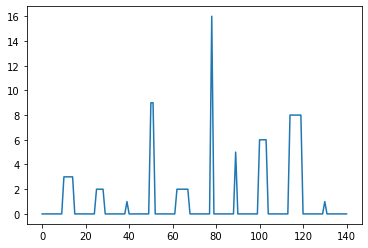

[0.8418335674607809, 0.8244464471718986, 0.785597193826268, 0.850249601049836, 0.843476437622436, 0.8876674985653727, 0.8128159417566959, 0.8502653628274395, 0.8843045595180778, 0.785597193826268]


In [38]:
ifnone = lambda a, b: b if a is None else a

op_slice = slice(300,310)
op_range = range(ifnone(op_slice.start, 0), op_slice.stop, ifnone(op_slice.step, 1))

anom_curves = []
gap_size = 10

filler_gap = [0 for _ in range(gap_size)]

anom_curves.extend(filler_gap)

for cur_ind in op_range:
    dur_val = dur_val_vec[cur_ind]
    dev_val = dev_val_vec[cur_ind]

    anom_curve = [dev_val for _ in range(dur_val)]
    anom_curves.extend(anom_curve)
    anom_curves.extend(filler_gap)

plt.plot(anom_curves)
plt.show()
print(op_scores[op_slice])